# Section 4.1

## Example 4.1.1

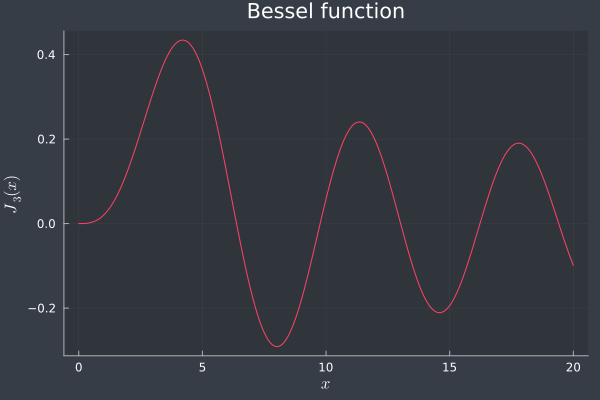

In [1]:
using Plots, LaTeXStrings, SpecialFunctions
theme(:dark)
J₃(x) = besselj(3, x)
plot(J₃, 0, 20;
    title="Bessel function", xaxis=(L"x"),  yaxis=(L"J_3(x)"),  grid=:xy, legend=false)

In [2]:
J₃(4)

0.43017147387562193

In [3]:
fun(x) = [J₃(x[1])]
fun([4])

1-element Vector{Float64}:
 0.43017147387562193

In [4]:
using NLsolve
s = nlsolve(fun, [5.0], ftol=1e-14)

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [5.0]
 * Zero: [6.380161895923983]
 * Inf-norm of residuals: 0.000000
 * Iterations: 5
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-14: true
 * Function Calls (f): 6
 * Jacobian Calls (df/dx): 6

In [5]:
s.zero

1-element Vector{Float64}:
 6.380161895923983

In [6]:
ω = []
for guess = [6., 10. ,13., 16., 19.]
    s = nlsolve(x -> J₃(x[1]), [guess], ftol=1e-14)
    push!(ω, s.zero[1])
end

In [7]:
y = J₃.(ω)
using PrettyTables
pretty_table([ω y];
    column_labels=["root estimate", "function value"], backend=:html) 

root estimate,function value
6.38016,2.47025e-15
9.76102,0.0
13.0152,-2.77556e-17
16.2235,6.93889e-18
19.4094,-9.71445e-17


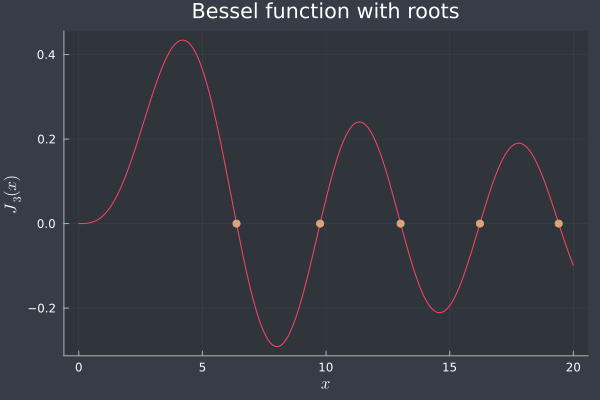

In [8]:
scatter!(ω, y, title="Bessel function with roots")

$$J_3(x)=0.2 \implies  J_3(x)-0.2 = 0$$

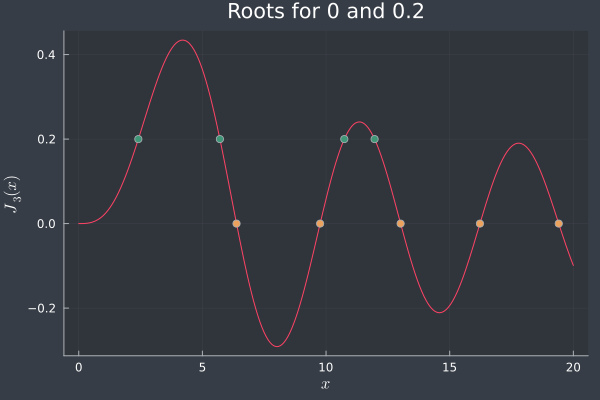

In [9]:
r = []
for guess = [3., 6., 10., 13.]
    f(x) = J₃(x[1]) - 0.2
    s = nlsolve(f, [guess], ftol=1e-14)
    append!(r, s.zero)
end
scatter!(r, J₃.(r), title="Roots for 0 and 0.2")

## Example 4.1.2

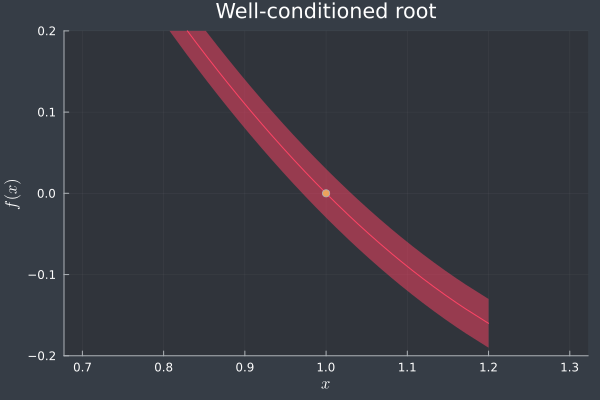

In [10]:
f(x) = (x - 1) * (x - 2);
interval = [0.8, 1.2]

using Plots, LaTeXStrings
plot(f, interval..., ribbon=0.03, aspect_ratio=1,
    xlabel=L"x", yaxis=(L"f(x)", [-0.2, 0.2]), legend=false)

scatter!([1], [0], title="Well-conditioned root")

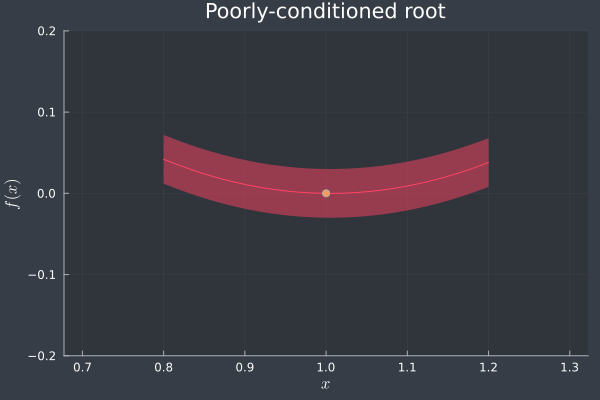

In [11]:
f(x) = (x - 1) * (x - 1.01);

plot(f, interval..., ribbon=0.03, aspect_ratio=1,
    xlabel=L"x", yaxis=(L"f(x)", [-0.2, 0.2]), legend=false)

scatter!([1], [0], title="Poorly-conditioned root")